In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from chemevo import evolution as evo

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': False, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

colors = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#F0E442"]

vals = np.linspace(1, 0.2, 6)
blues   = [plt.cm.Blues(v)   for v in vals]
purples = [plt.cm.Purples(v) for v in vals]
greens  = [plt.cm.Greens(v)  for v in vals]
grays   = [plt.cm.Greys(v)   for v in vals] 
tab20b = [plt.cm.tab20b(v) for v in vals]
def darken(color, factor=0.6):
    """Darken an RGBA color by a given factor (0–1)."""
    r, g, b, a = color
    return (r * factor, g * factor, b * factor, a)

tab20b_darker = [darken(c, factor=0.6) for c in tab20b]

In [2]:
t_array = np.linspace(0,12,int(1e3))
tau_sfh = 6 #Gyrs
m_g_array_exp = 1 * np.exp(-t_array/tau_sfh)
m_g_array_const = np.ones(len(t_array))

#Gal1, with everything
gal1 = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const)
Z_Fe_1 = gal1.compute_z_Fe()
Z_O_1 = gal1.compute_z_O()
Z_Mn_1 = gal1.compute_z_Mn()
Z_X = gal1.compute_z_X()

O_eq = gal1.analytic_eq_O(SFR_function='constant')
m_o_cc_solar = gal1.m_o_cc_arr[0] * gal1.SolarO/O_eq
print("m_o_cc to force solar values at equilibrium = ", m_o_cc_solar)


print("m_Fe_cc (default) = ", gal1.m_Fe_cc_arr[0])
print("m_O_cc (default) = ", gal1.m_o_cc_arr[0])
#print("Ratio of m_Fe_cc/m_o_cc = ", gal1.m_Fe_cc_arr[0]/gal1.m_o_cc_arr[0])
print("Ratio of solar values Z_Fe/Z_O = ", gal1.SolarFe/gal1.SolarO)
print("if fcc_Fe = 0.5, m_O_cc * fcc_Fe/fcc_O * solarFe/solarO = ", gal1.m_o_cc_arr[0] * gal1.SolarFe/gal1.SolarO * 0.5)

m_o_cc to force solar values at equilibrium =  0.01736
m_Fe_cc (default) =  0.0012
m_O_cc (default) =  0.015
Ratio of solar values Z_Fe/Z_O =  0.21428571428571427
if fcc_Fe = 0.5, m_O_cc * fcc_Fe/fcc_O * solarFe/solarO =  0.001607142857142857


In [3]:
def m_Fe_cc_no_met_dep(fcc_Fe, m_O_cc=gal1.m_o_cc_arr[0], solarFe = gal1.SolarFe, solarO = gal1.SolarO):
    m_Fe_cc_nometdep = m_O_cc * (solarFe/solarO) * fcc_Fe/1
    return m_Fe_cc_nometdep

def get_R_Ia(fcc):
    R_Ia = fcc**(-1) - 1
    return R_Ia

In [4]:
hyp_R_Ia_Fe = get_R_Ia(0.4)
print("R_Ia_Fe if f_cc_Fe = 0.4, will be = ", hyp_R_Ia_Fe)

R_Ia_Fe if f_cc_Fe = 0.4, will be =  1.5


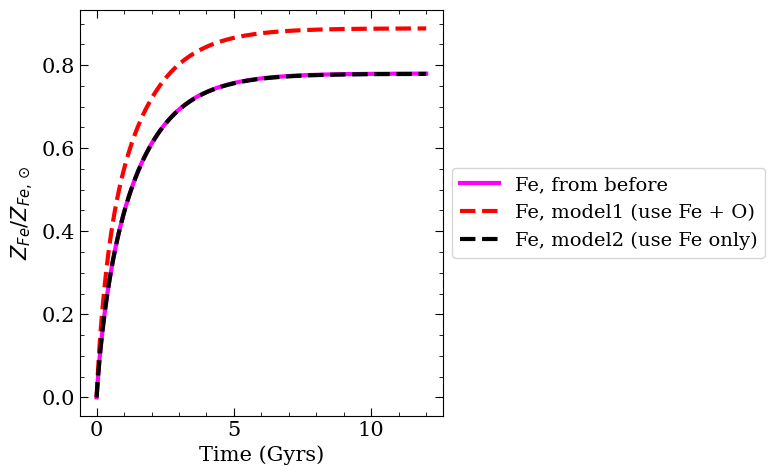

In [5]:
plt.figure(figsize=(8,5))
plt.plot(t_array, Z_Fe_1/gal1.SolarFe, label = 'Fe, from before', lw = 3, color = 'magenta')
plt.plot(t_array, gal1.compute_z_X(R_Ia_X=1)/gal1.SolarFe, label = 'Fe, model1 (use Fe + O)', color = 'red', linestyle='--', lw=3)
plt.plot(t_array, gal1.compute_z_X_with_Fe(R_Ia_X=1)/gal1.SolarFe, label = 'Fe, model2 (use Fe only)', linestyle='--', color = 'black', lw = 3)

plt.xlabel('Time (Gyrs)')
plt.ylabel(r"$Z_{Fe}/Z_{Fe,\odot}$")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()

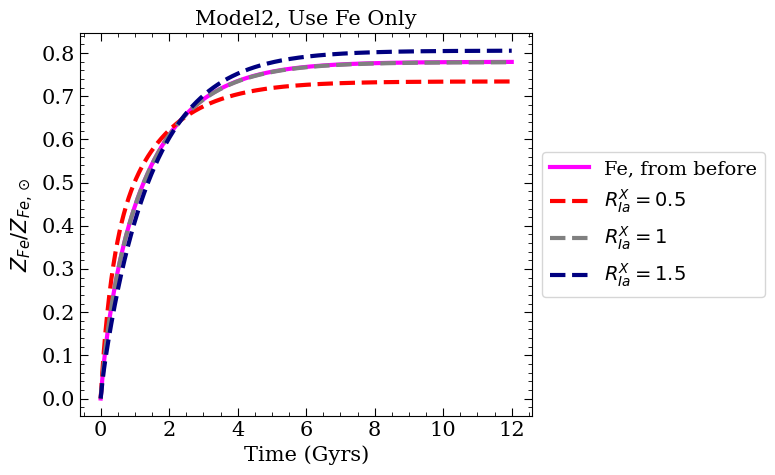

In [6]:
plt.figure(figsize=(8,5))
plt.plot(t_array, Z_Fe_1/gal1.SolarFe, label = 'Fe, from before', lw = 3, color = 'magenta')
plt.plot(t_array, gal1.compute_z_X_with_Fe(R_Ia_X=0.5)/gal1.SolarFe, label = r'$R_{Ia}^{X} = 0.5 $', color = 'red', linestyle='--', lw=3)
plt.plot(t_array, gal1.compute_z_X_with_Fe(R_Ia_X=1)/gal1.SolarFe, label =  r'$R_{Ia}^{X} = 1 $', linestyle='--', color = 'gray', lw = 3)
plt.plot(t_array, gal1.compute_z_X_with_Fe(R_Ia_X=1.5)/gal1.SolarFe, label =  r'$R_{Ia}^{X} = 1.5 $', linestyle='--', color = 'navy', lw = 3)

plt.xlabel('Time (Gyrs)')
plt.ylabel(r"$Z_{Fe}/Z_{Fe,\odot}$")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title('Model2, Use Fe Only')
plt.tight_layout()

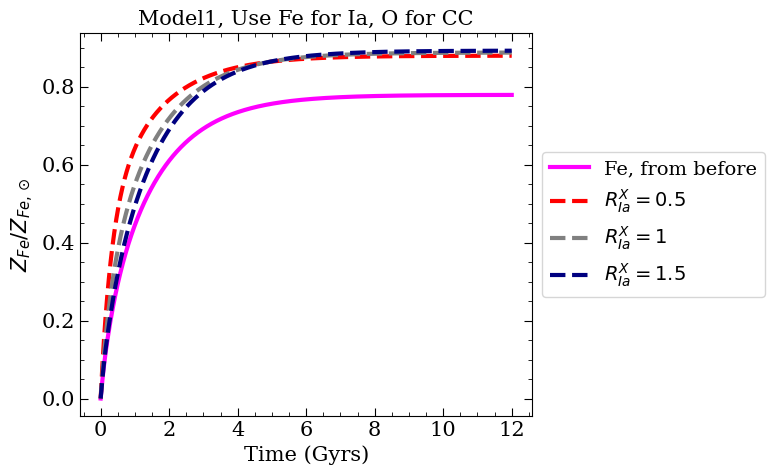

In [7]:
plt.figure(figsize=(8,5))
plt.plot(t_array, Z_Fe_1/gal1.SolarFe, label = 'Fe, from before', lw = 3, color = 'magenta')
plt.plot(t_array, gal1.compute_z_X(R_Ia_X=0.5)/gal1.SolarFe, label = r'$R_{Ia}^{X} = 0.5 $', color = 'red', linestyle='--', lw=3)
plt.plot(t_array, gal1.compute_z_X(R_Ia_X=1)/gal1.SolarFe, label =  r'$R_{Ia}^{X} = 1 $', linestyle='--', color = 'gray', lw = 3)
plt.plot(t_array, gal1.compute_z_X(R_Ia_X=1.5)/gal1.SolarFe, label =  r'$R_{Ia}^{X} = 1.5 $', linestyle='--', color = 'navy', lw = 3)

plt.xlabel('Time (Gyrs)')
plt.ylabel(r"$Z_{Fe}/Z_{Fe,\odot}$")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title('Model1, Use Fe for Ia, O for CC')
plt.tight_layout()

# Now let's do the same thing with Mn

## First, let's make sure get_z_Mn and get_z_x work the same

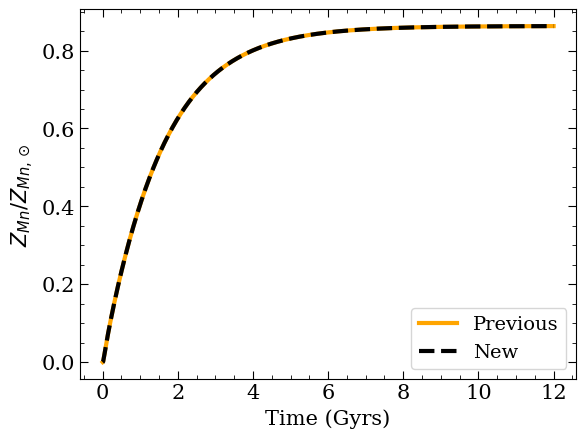

In [14]:
SolarMn = 1.29e-05
plt.plot(t_array, gal1.compute_z_Mn()/SolarMn, lw = 3, color = 'orange', label = 'Previous')
plt.plot(t_array, gal1.compute_z_X(R_Ia_X=1.97, alpha_cc_X=0.17, alpha_Ia_X=0.30, SolarX=SolarMn)/SolarMn,
         linestyle='--', lw=3, color = 'black', label = 'New')

plt.xlabel('Time (Gyrs)')
plt.ylabel(r'$Z_{Mn}/Z_{Mn,\odot}$')
plt.legend()

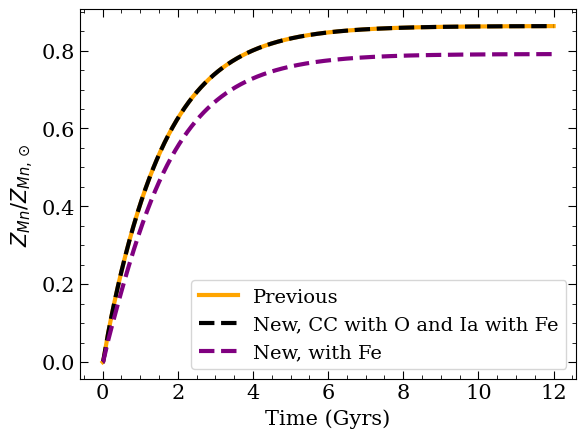

In [16]:
SolarMn = 1.29e-05
plt.plot(t_array, gal1.compute_z_Mn()/SolarMn, lw = 3, color = 'orange', label = 'Previous')
plt.plot(t_array, gal1.compute_z_X(R_Ia_X=1.97, alpha_cc_X=0.17, alpha_Ia_X=0.30, SolarX=SolarMn)/SolarMn,
         linestyle='--', lw=3, color = 'black', label = 'New, CC with O and Ia with Fe')
plt.plot(t_array, gal1.compute_z_X_with_Fe(R_Ia_X=1.97, alpha_cc_X=0.17, alpha_Ia_X=0.30, SolarX=SolarMn)/SolarMn,
         linestyle='--', lw=3, color = 'purple', label = 'New, with Fe')

plt.xlabel('Time (Gyrs)')
plt.ylabel(r'$Z_{Mn}/Z_{Mn,\odot}$')
plt.legend()